<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_11_desicion_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11: Árboles de desición


#Algoritmo CART (classification and regresion tree)

Se busca entrenar un modelo para categorizar la información encontrando la frontera de desición, permite tener una mejor interpretabilidad que las redes neuronales dado que se puede tener una represetancion grafica del proceso de desiscion secuencial.

- ref https://www.youtube.com/watch?v=kqaLlte6P6o&ab_channel=CodificandoBits
- Hand on Machine leargning




Dado un conjunto de caracteristicas se establece una condición que realiza
una particion binaria de los datos a clasificar repitiendo hasta encontrar
particiones lo más homogenea posible.




Text(0, 0.5, '$X_2$')

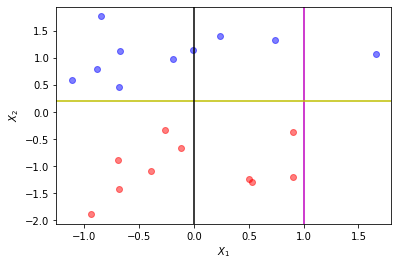

In [ ]:
X0, y0 = make_classification(n_samples=20,
    n_features=2, n_redundant=0, n_informative=1, random_state=1,
    n_clusters_per_class=1)

x=np.arange(-2, 3,1)
x_,y_ = np.meshgrid(x,x)

fig, ax = plt.subplots()
ax.plot(X0[:,0][y0==0],X0[:,1][y0==0],"ro", alpha=0.5)
ax.plot(X0[:,0][y0==1],X0[:,1][y0==1],"bo", alpha=0.5)
#ax.plot(x_,y_,"k.")

ax.axvline(x = 1, color = 'm', label="x1<=1")
ax.axhline(y = 0.2, color = 'y', label="x2<0.2")
ax.axvline(x = 0.0, color = 'k', label="x2<0.2")
#plt.legend(loc=3)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")


- Gini index


$G = 1 - (PC_1)^2 - (PC_2)^2$

$PC_1$: Probablidad categoria 1

$PC_2$: Probablidad categoria 2

Si :

- $G=0$ nodos puros, datos que pertenecen a una sola categoría

- Gini > 0 son nodos con impurezas, con mas de una categoría


La partición purpura  y amarilla del gráfico anterior representan nodos puros.

Mientras que la linea negra define:

- 7 puntos son de color azul.

- 6 puntos de color rojo.

$G = 1 - (7/13)^{2} - (6/13)^{2}$

mientrás que la ponderacion viene dada por:

$m = (7/20+7/20)=7/10$



No:

$G=1-(3/7)^{2}-(4/7)^{2}$
m = (3/20+4/20)


La funcion de coste, asocida al nodo padre:

$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right} $



# Algoritmo
1. Calcular todos los posibles condiciones.
2. Calcular los indices de Gini.
3. Encontrar la funcion de coste
4. Escoger la menor funcion de coste
5. Repetir.



1. Importar iris dataset
2. Generar una intuición respecto a iris dataset. Ver laboratorio anterior.
3. Dividir el *dataset* empleanto el metodo train_test_split de sklearn
4. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.
5. Para el clasificador analice el gráfico de desición:

```

https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

  fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
  graph=tree.plot_tree(clf,class_names = iris.target_names,\
                feature_names = iris.feature_names,\
                impurity=False, filled=True,rounded=True )

```

6. Características importantes.

```
clf.feature_importances_
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()
```

7. Fronteras de desición.



```
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Parameters
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

# Load data
iris = load_iris()

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Shuffle
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    # Standardize
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    plt.subplot(2, 3, pairidx + 1)
  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    cmap=plt.cm.Paired)

    plt.axis("tight")

plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend()
plt.show()
```


In [ ]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pylab as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
import graphviz
#from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree


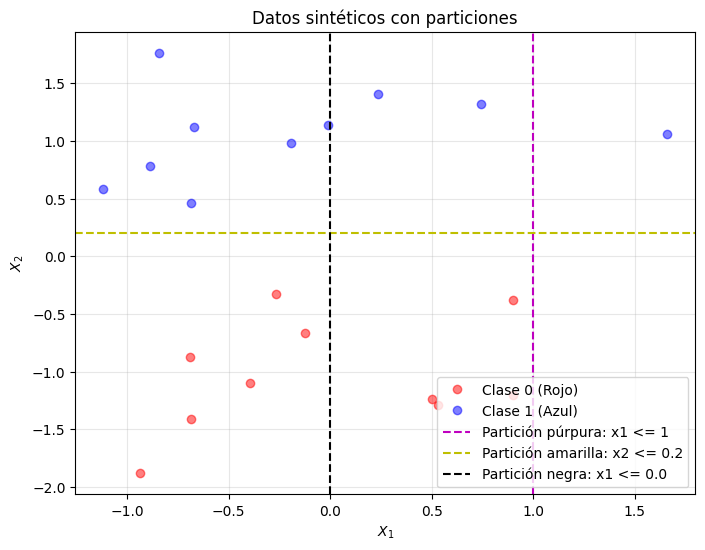

CÁLCULO DEL ÍNDICE DE GINI PARA LA PARTICIÓN NEGRA
Región izquierda (x1 <= 0.0): 7 azules, 6 rojos
Total de puntos en la región: 13
Proporción azules: 7/13 = 0.5385
Proporción rojos: 6/13 = 0.4615
Gini región izquierda = 1 - (7/13)^2 - (6/13)^2
Gini región izquierda = 0.4970

Ponderación correcta m_left/m = 13/20 = 0.6500

Nota: La expresión m = (3/20 + 4/20) es INCORRECTA.
La ponderación se calcula como el número total de muestras en la región
dividido por el número total de muestras en el nodo padre.



PARTE 2: ÁRBOL DE DECISIÓN CON IRIS DATASET

Características del dataset Iris:
  Número de muestras: 150
  Número de características: 4
  Clases: ['setosa' 'versicolor' 'virginica']
  Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Primeras 5 filas del dataset:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Etiquetas correspondientes:
[0 0 0 0 0]

Tamaño del conjunto de entrenamiento

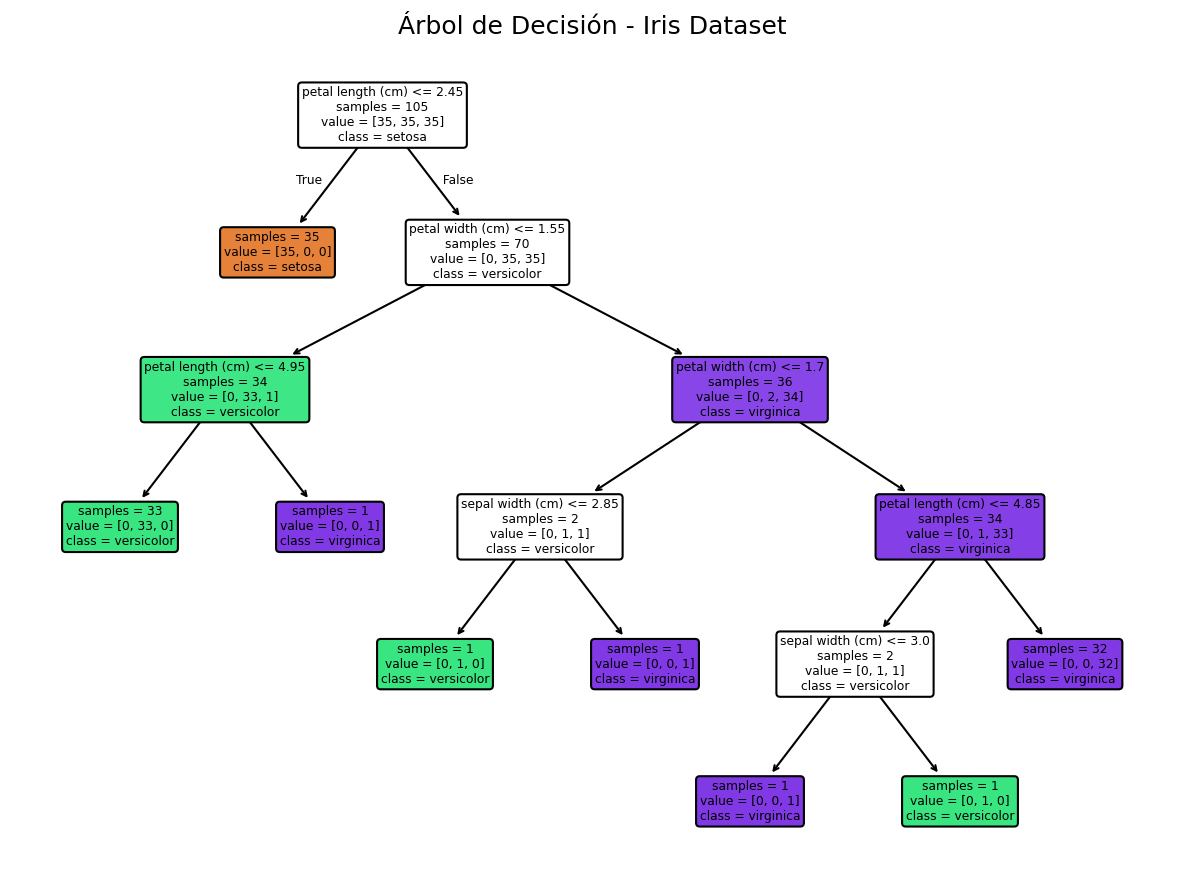


Importancia de las características:
  sepal length (cm): 0.0000
  sepal width (cm): 0.0286
  petal length (cm): 0.5412
  petal width (cm): 0.4303


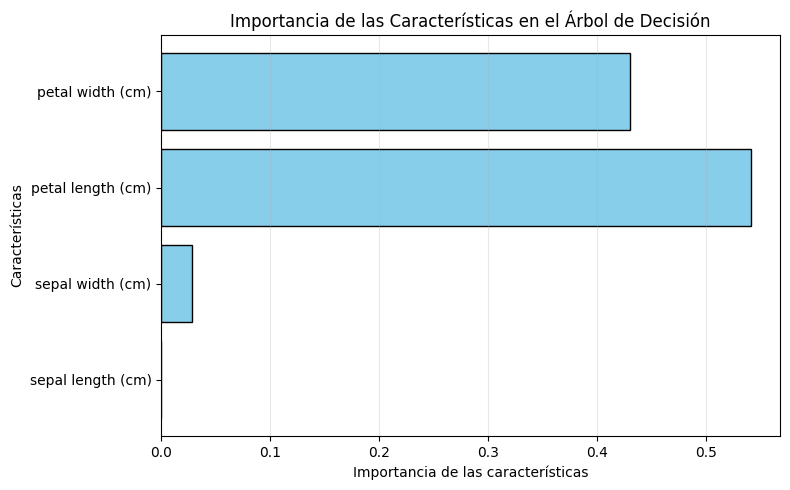

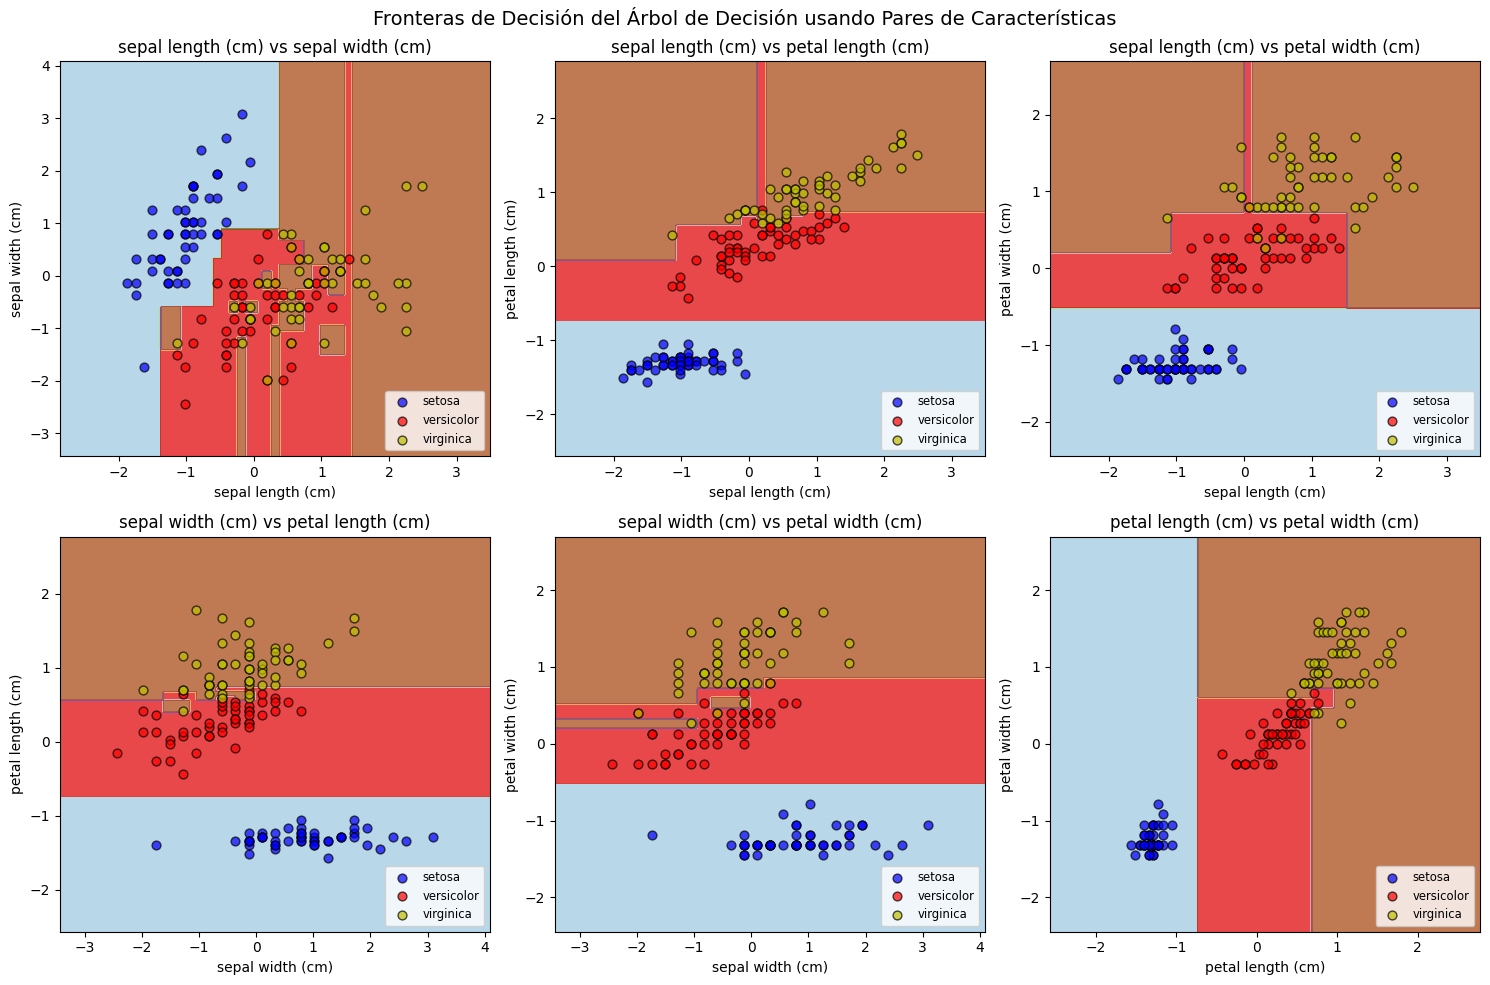


LABORATORIO COMPLETADO


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import export_graphviz

# =============================================================================
# PARTE 1: EJEMPLO SINTÉTICO Y CÁLCULO DEL ÍNDICE DE GINI
# =============================================================================

# Generar datos sintéticos
X0, y0 = make_classification(n_samples=20,
    n_features=2, n_redundant=0, n_informative=1, random_state=1,
    n_clusters_per_class=1)

# Crear malla para fondo del gráfico
x = np.arange(-2, 3, 1)
x_, y_ = np.meshgrid(x, x)

# Visualizar datos y particiones
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X0[:, 0][y0 == 0], X0[:, 1][y0 == 0], "ro", alpha=0.5, label="Clase 0 (Rojo)")
ax.plot(X0[:, 0][y0 == 1], X0[:, 1][y0 == 1], "bo", alpha=0.5, label="Clase 1 (Azul)")

# Líneas de partición
ax.axvline(x=1, color='m', linestyle='--', label="Partición púrpura: x1 <= 1")
ax.axhline(y=0.2, color='y', linestyle='--', label="Partición amarilla: x2 <= 0.2")
ax.axvline(x=0.0, color='k', linestyle='--', label="Partición negra: x1 <= 0.0")

plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Datos sintéticos con particiones")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------------------------------------------------
# Cálculo del índice de Gini para la partición negra (x1 <= 0.0)
# -----------------------------------------------------------------------------
# La línea vertical negra (x1 <= 0.0) divide los datos de la siguiente manera:
#   - Región izquierda (x1 <= 0.0): contiene 7 puntos azules y 6 puntos rojos.
#   - Región derecha (x1 > 0.0): contiene los puntos restantes.
# A continuación se calcula el Gini para la región izquierda.

# Número de puntos en la región izquierda según la descripción
azules_izquierda = 7
rojos_izquierda = 6
total_izquierda = azules_izquierda + rojos_izquierda  # 13

# Índice de Gini para la región izquierda (nodo con impureza)
G_izquierda = 1 - (azules_izquierda / total_izquierda)**2 - (rojos_izquierda / total_izquierda)**2
print("=" * 60)
print("CÁLCULO DEL ÍNDICE DE GINI PARA LA PARTICIÓN NEGRA")
print("=" * 60)
print(f"Región izquierda (x1 <= 0.0): {azules_izquierda} azules, {rojos_izquierda} rojos")
print(f"Total de puntos en la región: {total_izquierda}")
print(f"Proporción azules: {azules_izquierda}/{total_izquierda} = {azules_izquierda/total_izquierda:.4f}")
print(f"Proporción rojos: {rojos_izquierda}/{total_izquierda} = {rojos_izquierda/total_izquierda:.4f}")
print(f"Gini región izquierda = 1 - ({azules_izquierda}/{total_izquierda})^2 - ({rojos_izquierda}/{total_izquierda})^2")
print(f"Gini región izquierda = {G_izquierda:.4f}")

# Ponderación correcta
total_padre = 20  # nodo padre (dataset completo)
ponderacion_izquierda = total_izquierda / total_padre
print(f"\nPonderación correcta m_left/m = {total_izquierda}/{total_padre} = {ponderacion_izquierda:.4f}")
print("\nNota: La expresión m = (3/20 + 4/20) es INCORRECTA.")
print("La ponderación se calcula como el número total de muestras en la región")
print("dividido por el número total de muestras en el nodo padre.")
print("=" * 60)

# =============================================================================
# PARTE 2: APLICACIÓN CON EL DATASET IRIS
# =============================================================================

print("\n\n")
print("=" * 60)
print("PARTE 2: ÁRBOL DE DECISIÓN CON IRIS DATASET")
print("=" * 60)

# 1. Importar iris dataset
iris = load_iris()
X = iris.data
y = iris.target

print("\nCaracterísticas del dataset Iris:")
print(f"  Número de muestras: {X.shape[0]}")
print(f"  Número de características: {X.shape[1]}")
print(f"  Clases: {iris.target_names}")
print(f"  Características: {iris.feature_names}")

# 2. Intuición respecto al dataset (información básica)
print("\nPrimeras 5 filas del dataset:")
print(X[:5])
print("\nEtiquetas correspondientes:")
print(y[:5])

# 3. División del dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

# 4. Aplicar el algoritmo DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluación del modelo
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
print(f"\nPrecisión en entrenamiento: {train_accuracy:.4f}")
print(f"Precisión en prueba: {test_accuracy:.4f}")

# 5. Gráfico del árbol de decisión
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), dpi=150)
plot_tree(clf,
          class_names=iris.target_names.tolist(),
          feature_names=iris.feature_names,
          impurity=False,
          filled=True,
          rounded=True,
          ax=axes)
plt.title("Árbol de Decisión - Iris Dataset")
plt.tight_layout()
plt.show()

# 6. Importancia de las características
caract = X.shape[1]
importancias = clf.feature_importances_

print("\nImportancia de las características:")
for nombre, importancia in zip(iris.feature_names, importancias):
    print(f"  {nombre}: {importancia:.4f}")

plt.figure(figsize=(8, 5))
plt.barh(range(caract), importancias, color='skyblue', edgecolor='black')
plt.yticks(np.arange(caract), iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title('Importancia de las Características en el Árbol de Decisión')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Fronteras de decisión para pares de características
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

pares = [[0, 1], [0, 2], [0, 3],
         [1, 2], [1, 3], [2, 3]]

for pairidx, pair in enumerate(pares):
    # Seleccionar solo las dos características correspondientes
    X_sub = iris.data[:, pair]
    y = iris.target

    # Mezclar los datos
    idx = np.arange(X_sub.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X_sub = X_sub[idx]
    y = y[idx]

    # Estandarizar
    mean = X_sub.mean(axis=0)
    std = X_sub.std(axis=0)
    X_std = (X_sub - mean) / std

    # Entrenar clasificador con este par de características
    clf_pair = DecisionTreeClassifier(random_state=42).fit(X_std, y)

    # Crear malla para visualizar frontera de decisión
    x_min, x_max = X_std[:, 0].min() - 1, X_std[:, 0].max() + 1
    y_min, y_max = X_std[:, 1].min() - 1, X_std[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    # Predecir para cada punto de la malla
    Z = clf_pair.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar frontera de decisión
    ax = axes[pairidx]
    cs = ax.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

    ax.set_xlabel(iris.feature_names[pair[0]])
    ax.set_ylabel(iris.feature_names[pair[1]])

    # Graficar puntos de entrenamiento
    for i, color in zip(range(n_classes), plot_colors):
        idx_clase = np.where(y == i)
        ax.scatter(X_std[idx_clase, 0], X_std[idx_clase, 1],
                   c=color, label=iris.target_names[i],
                   edgecolor='k', s=40, alpha=0.7)

    ax.set_title(f"{iris.feature_names[pair[0]]} vs {iris.feature_names[pair[1]]}")
    ax.legend(loc='lower right', fontsize='small')

plt.suptitle("Fronteras de Decisión del Árbol de Decisión usando Pares de Características",
             fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("LABORATORIO COMPLETADO")
print("=" * 60)